In [1]:
import numpy as np
import matplotlib.pyplot as plt

units = np.load('../Data/units.npy',allow_pickle=True)
# reaction time
reaction = np.load('../Data/reaction.npy',allow_pickle=True)
letters  = np.load('../Data/letters_sep.npy',allow_pickle=True)
probes   = np.load('../Data/probes_sep.npy',allow_pickle=True)
uniqueLetters = np.array([p for p in np.unique(np.concatenate(letters)) if p not in ['Q', 'W', 'X']])
print(uniqueLetters)

setsize  = [
           np.array([np.sum([1 if u in letterString else 0 for u in uniqueLetters]) for letterString in ls],dtype=int)
           for ls in letters]

subj = np.load('../Data/subjs_sep.npy',allow_pickle=True)
subj = [s[0] for s in subj]
info = np.load('../Data/trial_corrInfo.npy',allow_pickle=True)

['B' 'C' 'D' 'F' 'G' 'H' 'K' 'L' 'N' 'P' 'R' 'S' 'T' 'V' 'Z']


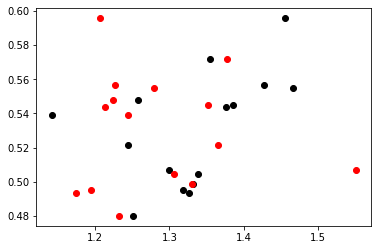

In [2]:
from scipy.stats import spearmanr, pearsonr
plt.rcParams.update({'font.size': 22})

thrC    = 0
corr_letter_all = []
setREF  = [4,6,8]
respREF = [52]
rmSUB   = [40, 43, 44, 45, 47, 53, 57, 58, 61, 63, 64]
for u in uniqueLetters:
    corr_letter = []
    for s in np.unique(subj):
        if s in rmSUB:
            mask        = np.where(subj==s)[0]
            #probe_subj  = np.concatenate(letters[mask],axis=0)
            probe_subj  = np.concatenate(probes[mask],axis=0)
            corr_subj   = np.concatenate(info[mask],axis=0)[:,-1]
            corr_subj   = corr_subj[np.where(np.logical_and(
                                             np.logical_and(np.concatenate(info[mask],axis=0)[:,1],
                                                            [m in respREF for m in np.concatenate(info[mask],axis=0)[:,3]]),
                                                            [m in setREF for m in np.concatenate(info[mask],axis=0)[:,0]]))[0]]
            #mask_u = np.where([u in l for l in probe_subj])[0]
            resp   = np.concatenate(info[mask],axis=0)[np.concatenate(info[mask],axis=0)[:,1]==True,3]
            setR   = np.concatenate(info[mask],axis=0)[np.concatenate(info[mask],axis=0)[:,1]==True,0]

            probe_subj = probe_subj[np.logical_and([r in respREF for r in resp],[r in setREF for r in setR])]
            mask_u = np.where(probe_subj==u)[0]
            corr_letter.extend([np.median(corr_subj[mask_u])])
    corr_letter_all.append(corr_letter)
corr_letter_all = np.array(corr_letter_all,dtype=object)
    #print(u,np.mean(corr_letter))
    
letter_acc = []
area_prefix = 'HYP'
for k in range(50):
    al_real = []
    all_Letters = np.load(f'../../FC_letter_decoding_updated/v2/Results/single_letter_50_{k}.npy')
    #all_Letters = np.load(f'../single_letter_set4_all_{k}.npy')
    #all_Letters = np.load(f'../single_letter_{area_prefix}_{k}.npy')
    for letter_index in range(15):       
        al_real.append(np.diag(all_Letters[letter_index]))
    al_real = np.array(al_real)  # shape: (n_subjects, n_times)
    letter_acc.append(al_real)
letter_acc = np.array(letter_acc)
letter_acc.shape
letter_acc = np.median(letter_acc,axis=0)
T1 = 2
T2 = 16
letter_acc = np.array(np.cumsum(letter_acc[:,T1:T2],axis=-1)/(T2-T1))[:,-1]

m52 = []
for i in range(15):
    plt.scatter(np.median(np.array(corr_letter_all)[i]),
                np.array(letter_acc)[i],alpha=1,color='k')
    
    m52.append(np.median(np.array(corr_letter_all)[i]))

corr_letter_all = []
respREF         = [51]
for u in uniqueLetters:
    corr_letter = []
    for s in np.unique(subj):
        if s in rmSUB:
            mask        = np.where(subj==s)[0]
            #probe_subj  = np.concatenate(letters[mask],axis=0)
            probe_subj  = np.concatenate(probes[mask],axis=0)
            corr_subj   = np.concatenate(info[mask],axis=0)[:,-1]
            corr_subj   = corr_subj[np.where(np.logical_and(
                                             np.logical_and(np.concatenate(info[mask],axis=0)[:,1],
                                                            [m in respREF for m in np.concatenate(info[mask],axis=0)[:,3]]),
                                                            [m in setREF for m in np.concatenate(info[mask],axis=0)[:,0]]))[0]]
            #mask_u = np.where([u in l for l in probe_subj])[0]
            resp   = np.concatenate(info[mask],axis=0)[np.concatenate(info[mask],axis=0)[:,1]==True,3]
            setR   = np.concatenate(info[mask],axis=0)[np.concatenate(info[mask],axis=0)[:,1]==True,0]

            probe_subj = probe_subj[np.logical_and([r in respREF for r in resp],[r in setREF for r in setR])]
            mask_u = np.where(probe_subj==u)[0]
            corr_letter.extend([np.median(corr_subj[mask_u])])
    corr_letter_all.append(corr_letter)
corr_letter_all = np.array(corr_letter_all,dtype=object)
    #print(u,np.mean(corr_letter))
    
m51 = []
for i in range(15):
    plt.scatter(np.median(np.array(corr_letter_all)[i]),
                np.array(letter_acc)[i],alpha=1,color='red')
    m51.append(np.median(np.array(corr_letter_all)[i]))

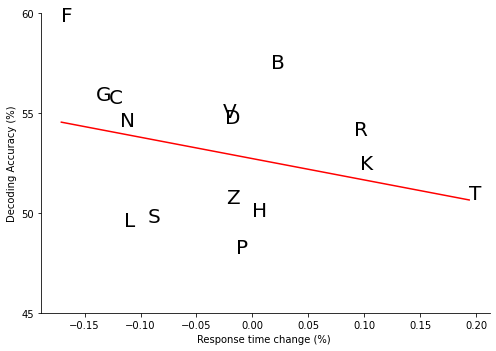

Pearson  PearsonRResult(statistic=-0.32560952947875016, pvalue=0.23629563397394765)
Spearman SignificanceResult(statistic=-0.36785714285714277, pvalue=0.17734214689349137)
Kendall  SignificanceResult(statistic=-0.29523809523809524, pvalue=0.13946285911906778)


In [3]:
setLETTER = ['F','K','D','V','N','C','S','H','Z','B','G','T','R',
            'P','L'
            ]
wL        = [np.where(uniqueLetters==sL)[0][0] for sL in setLETTER]

m = (np.array(m51)-np.array(m52))/np.array(m52)
#m = np.array(m52)
m_L =m[wL]
letter_acc_L = letter_acc[wL]

#plt.scatter(m,letter_acc)
thrC = 0
from scipy.stats import kendalltau
pearson_corr = np.corrcoef(m_L[letter_acc_L>thrC],letter_acc_L[letter_acc_L>thrC])[0, 1]
# Spearman correlation
spearman_corr, _ = spearmanr(m_L[letter_acc_L>thrC],letter_acc_L[letter_acc_L>thrC])

kendall_corr = kendalltau(m_L[letter_acc_L>thrC],letter_acc_L[letter_acc_L>thrC])

#print("Pearson correlation:", pearson_corr)
#print("Spearman correlation:", spearman_corr)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, linregress

# Your existing data setup
letter_acc = np.array(letter_acc)

fig,ax = plt.subplots(figsize=(7,5))
# Scatter plot
#plt.scatter(m[letter_acc>thrC], letter_acc[letter_acc>thrC], alpha=1, label='Data points',color='k')
for l in range(len(uniqueLetters)):
    if(l in wL):
        plt.text(m[l],letter_acc[l],uniqueLetters[l],fontsize=20,color='black')
    else:
        plt.text(m[l],letter_acc[l],uniqueLetters[l],fontsize=20,color='gray')

# Compute correlations
pearson_corr = np.corrcoef(m_L[letter_acc_L>thrC], letter_acc_L[letter_acc_L>thrC])[0, 1]
spearman_corr, _ = spearmanr(m_L[letter_acc_L>thrC], letter_acc_L[letter_acc_L>thrC])

# Linear regression fit
slope, intercept, r_value, p_value, std_err = linregress(m_L[letter_acc_L>thrC], letter_acc_L[letter_acc_L>thrC])
x_fit = np.linspace(np.min(m_L[letter_acc_L>thrC]), np.max(m_L[letter_acc_L>thrC]), 100)
y_fit = slope * x_fit + intercept

# Compute 95% confidence interval for regression line
# Formula: y_pred ± t_crit * SE
from scipy import stats

n = len(m[letter_acc>thrC])
t_crit = stats.t.ppf(1 - 0.025, df=n - 2)
mean_x = np.mean(m_L[letter_acc_L>thrC])
se_line = std_err * np.sqrt(1/n + (x_fit - mean_x)**2 / np.sum((m - mean_x)**2))

y_upper = y_fit + t_crit * se_line
y_lower = y_fit - t_crit * se_line

# Plot line and confidence interval
plt.plot(x_fit, y_fit, color='red', label='Line fit')
#plt.fill_between(x_fit, y_lower, y_upper, color='gray', alpha=0.2, label='95% CI',linewidth=0)

# Labels and legend
plt.xlabel("Response time change (%) ")
plt.ylabel("Decoding Accuracy (%)")
#plt.title(f"Pearson r = {pearson_corr:.2f}, Spearman ρ = {spearman_corr:.2f}")
#plt.legend(bbox_to_anchor=(1.1, 1.05))
plt.yticks([0.45,0.50,0.55,0.6],[45,50,55,60])
#plt.xticks([0,-0.1,-0.2],[0,-10,-20])
#plt.ylim(0.47,0.61)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
#plt.savefig('respTIME_Letter.svg',dpi=200)
plt.show()

#print("Pearson correlation:", pearson_corr)
#print("Spearman correlation:", spearman_corr)
#print("Kendall tau correlation:", kendall_corr)
print('Pearson ',pearsonr(m_L[letter_acc_L>thrC],letter_acc_L[letter_acc_L>thrC]))
print('Spearman',spearmanr(m_L[letter_acc_L>thrC], letter_acc_L[letter_acc_L>thrC]))
print('Kendall ',kendalltau(m_L[letter_acc_L>thrC], letter_acc_L[letter_acc_L>thrC]))

Permutation test (diff in medians) p = 0.29617038296170384


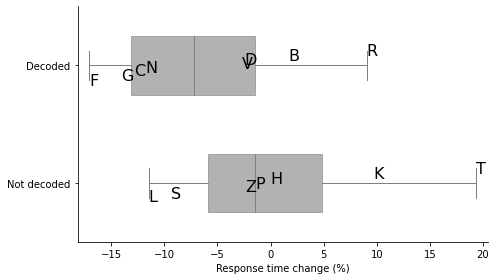

Welch t-test p = 0.2081407999880535
Mann–Whitney U p = 0.1205905205905206


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, t
thrACC = 0.525
# --- Compute m exactly as before ---
m = ((np.array(m51) - np.array(m52)) / np.array(m52)) * 100
#m = np.array(m51) 
# --- Threshold and groups (0.52) ---
thr = thrACC
letter_acc = np.array(letter_acc)

idx_high = letter_acc > thr
idx_low  = ~idx_high

m_high = m[idx_high]
m_low  = m[idx_low]

# --- Stats: Welch t-test ---
t_stat, p_t = ttest_ind(m_high, m_low, equal_var=False)

# --- Permutation test (independent samples, two-sided) ---
def permutation_test_independent(x, y, n_perm=20000, alternative='two-sided', rng=None):
    """
    Permutation test for difference in means between two independent samples.

    H0: distributions are the same.
    H1 (two-sided): mean(x) - mean(y) != 0
        (also supports 'greater' and 'less' if needed)
    """
    x = np.asarray(x)
    y = np.asarray(y)

    obs_diff = np.median(x) - np.median(y)

    if rng is None:
        rng = np.random.default_rng(10)

    combined = np.concatenate([x, y])
    n_x = len(x)
    n_total = len(combined)

    perm_diffs = np.empty(n_perm)
    for i in range(n_perm):
        idx = rng.permutation(n_total)
        perm_x = combined[idx[:n_x]]
        perm_y = combined[idx[n_x:]]
        perm_diffs[i] = np.mean(perm_x) - np.mean(perm_y)

    if alternative == 'two-sided':
        p_value = (np.sum(np.abs(perm_diffs) >= abs(obs_diff)) + 1) / (n_perm + 1)
    elif alternative == 'greater':
        p_value = (np.sum(perm_diffs >= obs_diff) + 1) / (n_perm + 1)
    elif alternative == 'less':
        p_value = (np.sum(perm_diffs <= obs_diff) + 1) / (n_perm + 1)
    else:
        raise ValueError("alternative must be 'two-sided', 'greater', or 'less'")

    return obs_diff, p_value

perm_stat, p_perm = permutation_test_independent(m_high, m_low, n_perm=10000, alternative='two-sided')
print("Permutation test (diff in medians) p =", p_perm)

# --- Horizontal boxplot + jittered text labels ---
fig, ax = plt.subplots(figsize=(7,4))

# Horizontal boxplot
box = ax.boxplot([m_low, m_high],
                 patch_artist=True,
                 widths=0.5,
                 vert=False)  # <── horizontal

# Gray boxes
for b in box['boxes']:
    b.set_facecolor('gray')
    b.set_edgecolor('gray')
    b.set_alpha(0.6)

for element in ['whiskers', 'caps', 'medians']:
    for item in box[element]:
        item.set_color('gray')

# Base positions for jittering on y-axis (now categories are on y)
base_low, base_high = 1.0, 2.0

letters = np.array(uniqueLetters)
letters_low = letters[idx_low]
letters_high = letters[idx_high]

low_sorted  = sorted(zip(m_low,  letters_low),  key=lambda x: x[0])
high_sorted = sorted(zip(m_high, letters_high), key=lambda x: x[0])

def spaced_jitter(n, base_y, target_min_sep=0.035, max_half_width=0.12, epsilon_frac=0.3):
    if n <= 1:
        return np.array([base_y])
    needed_half_width = max_half_width
    step = 2 * needed_half_width / (n - 1)
    if step < target_min_sep:
        needed_half_width = (target_min_sep * (n - 1)) / 2.0
    ys = np.linspace(-needed_half_width, needed_half_width, n) + base_y
    epsilon = target_min_sep * epsilon_frac
    ys += np.random.uniform(-epsilon, epsilon, size=n)
    return ys

# jittered Y-positions
y_low  = spaced_jitter(len(low_sorted),  base_low)
y_high = spaced_jitter(len(high_sorted), base_high)

# place letters (x=value, y=jittered)
for (x, lab), y in zip(low_sorted, y_low):
    ax.text(x, y, lab, fontsize=16, va='center', ha='left')
for (x, lab), y in zip(high_sorted, y_high):
    ax.text(x, y, lab, fontsize=16, va='center', ha='left')

# expand x-limits to cover all values
if len(m) > 0:
    x_min, x_max = np.min(m), np.max(m)
    margin = 0.03*(x_max-x_min if x_max> x_min else 1.0)
    ax.set_xlim(x_min - margin, x_max + margin)

# Formatting
ax.set_xlabel("Response time change (%)")
ax.set_yticks([1, 2])
ax.set_yticklabels(["Not decoded", "Decoded"])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
#plt.savefig('resp_box2.svg',dpi=200)
plt.show()

print("Welch t-test p =", p_t)

from scipy.stats import mannwhitneyu
u_stat, p_u = mannwhitneyu(m_low, m_high, alternative='two-sided')
print("Mann–Whitney U p =", p_u)

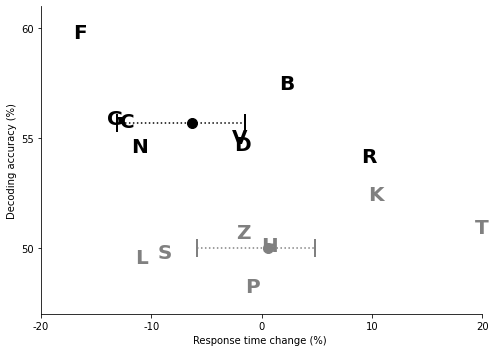

Pearson correlation: -0.3256095294787502
Spearman correlation: -0.36785714285714277
Kendall tau correlation: SignificanceResult(statistic=-0.29523809523809524, pvalue=0.13946285911906778)
PearsonRResult(statistic=-0.32560952947875027, pvalue=0.23629563397394765)
SignificanceResult(statistic=-0.36785714285714277, pvalue=0.17734214689349137)


In [5]:
m = (np.array(m51)-np.array(m52))/np.array(m52)
#m = np.array(m51)
from scipy.stats import kendalltau, spearmanr, linregress
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

letter_acc = np.array(letter_acc)

fig,ax = plt.subplots(figsize=(7,5))

# Plot each letter with conditional formatting
for l in range(len(uniqueLetters)):
    if letter_acc[l] > thrACC:
        plt.text(m[l], letter_acc[l], uniqueLetters[l],
                 fontsize=20, fontweight='bold', color='black')
    else:
        plt.text(m[l], letter_acc[l], uniqueLetters[l],
                 fontsize=20, fontweight='bold', color='gray')


thrC = thrACC
hi_mask = letter_acc > thrC
lo_mask = ~hi_mask  # <= thrC

def centroid_with_xiqr(x, y, mask):
    xm = np.mean(x[mask]);  ym = np.mean(y[mask])
    x25, x75 = np.percentile(x[mask], [25, 75])
    return xm, ym, x25, x75, np.sum(mask)

# compute
x_hi, y_hi, x25_hi, x75_hi, n_hi = centroid_with_xiqr(m, letter_acc, hi_mask)
x_lo, y_lo, x25_lo, x75_lo, n_lo = centroid_with_xiqr(m, letter_acc, lo_mask)

# plot: centroid dot + IQR line on x only
if n_hi > 0:
    ax.scatter(x_hi, y_hi, s=100, color='k', zorder=6)
    ax.hlines(y_hi, x25_hi, x75_hi, colors='k', linewidth=1.5, zorder=-1,linestyle='dotted')
    ax.vlines([x25_hi, x75_hi], y_hi-0.004, y_hi+0.004, colors='k', linewidth=2, zorder=5)  # optional caps

if n_lo > 0:
    ax.scatter(x_lo, y_lo, s=100, color='gray', zorder=6)
    ax.hlines(y_lo, x25_lo, x75_lo, colors='gray', linewidth=1.5, zorder=-1,linestyle='dotted')
    ax.vlines([x25_lo, x75_lo], y_lo-0.004, y_lo+0.004, colors='gray', linewidth=2, zorder=5)  # optional caps
# --- end centroids block ---

#plt.legend(frameon=False)
# --- end centroids block ---        

# Correlations
thrC = 0
pearson_corr = np.corrcoef(m[letter_acc>thrC], letter_acc[letter_acc>thrC])[0,1]
spearman_corr, _ = spearmanr(m[letter_acc>thrC], letter_acc[letter_acc>thrC])
kendall_corr = kendalltau(m[letter_acc>thrC], letter_acc[letter_acc>thrC])

# Regression
slope, intercept, r_value, p_value, std_err = linregress(m[letter_acc>thrC], letter_acc[letter_acc>thrC])
x_fit = np.linspace(np.min(m[letter_acc>thrC]), np.max(m[letter_acc>thrC]), 100)
y_fit = slope * x_fit + intercept

# 95% CI
n = len(m[letter_acc>thrC])
t_crit = stats.t.ppf(1 - 0.025, df=n - 2)
mean_x = np.mean(m[letter_acc>thrC])
se_line = std_err * np.sqrt(1/n + (x_fit - mean_x)**2 / np.sum((m - mean_x)**2))
y_upper = y_fit + t_crit * se_line
y_lower = y_fit - t_crit * se_line

#plt.plot(x_fit, y_fit, color='red', label='Line fit')

plt.xlabel("Response time change (%) ")
plt.ylabel("Decoding accuracy (%)")
plt.yticks([0.5,0.55,0.6],[50,55,60])
plt.xticks([0,-0.1,-0.2,0.1,0.2],[0,-10,-20,10,20])
plt.ylim(0.47,0.61)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
#plt.savefig('letterDEC_groups.svg',dpi=200)
plt.show()

print("Pearson correlation:", pearson_corr)
print("Spearman correlation:", spearman_corr)
print("Kendall tau correlation:", kendall_corr)
print(pearsonr(m[letter_acc>thrC],letter_acc[letter_acc>thrC]))
print(spearmanr(m[letter_acc>thrC], letter_acc[letter_acc>thrC]))